# Notebook 06: Consolidação por Edifício e Viés de Verticalização no CDI

O CDI é a peça central do `PCI_empírico = 1/CDI`. Para que seja **justo entre regiões com diferentes perfis construtivos**, é necessário entender o viés introduzido pela verticalização: um edifício com 200 apartamentos tem CDI=200, o que gera PCI_emp=0,005, penalização muito mais severa que o PCI arbitrário de 0,5.


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETA_REGIONAL = {
    'BARREIRO': '#e41a1c', 'CENTRO-SUL': '#377eb8', 'HIPERCENTRO': '#ff7f00',
    'LESTE': '#4daf4a', 'NORDESTE': '#984ea3', 'NOROESTE': '#a65628',
    'NORTE': '#f781bf', 'OESTE': '#999999', 'PAMPULHA': '#66c2a5',
    'VENDA NOVA': '#fc8d62',
}

# Dados originais (nível registro) — cnefe_master_metrics.parquet já contém CDI/CCR/DRS
metrics = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')

print(f'Registros originais: {len(metrics):,}')

Registros originais: 1,172,902


## 0. Consolidação de Edifícios: de Registros para Unidades Físicas

O CNEFE registra **unidades de endereço** (apartamentos, casas, estabelecimentos), não edifícios. Um prédio com 200 apartamentos gera 200 registros com a mesma coordenada GPS, o que infla o CDI e distorce qualquer análise que soma ou média por ponto.

A consolidação agrupa registros que pertencem ao mesmo edifício físico usando a chave:

> **logradouro + número + coordenada GPS arredondada a 1 m**

O CEP foi intencionalmente excluído da chave porque pode variar entre unidades do mesmo edifício (apartamentos em andares diferentes recebem CEPs distintos em alguns municípios), o que impede a consolidação correta.

Cada grupo → 1 registro representativo com métricas agregadas (mediana para GCI/LCI/MCI/distâncias; `first` para atributos de identidade; contagem de unidades).

O resultado é salvo em `cnefe_edificios.parquet`, consumido pelo NB07 em diante para análises em escala de edificação.

In [2]:
def build_consolidation_key(df):
    """Chave: logradouro + número + coordenada GPS (arredondada a 1 m).
    CEP excluído: varia entre unidades do mesmo edifício."""
    logra = df['DSC_LOCALIDADE'].fillna('').astype(str).str.upper().str.strip()
    num   = df['LOGRAD_NUM'].fillna('').astype(str).str.strip()
    x = df.geometry.x.round(0).astype(int).astype(str)
    y = df.geometry.y.round(0).astype(int).astype(str)
    return logra + '|' + num + '|' + x + '|' + y

metrics['edificio_key'] = build_consolidation_key(metrics)

key_vc      = metrics['edificio_key'].value_counts()
n_edificios = len(key_vc)
n_vertical  = (key_vc > 1).sum()
n_reg_vert  = key_vc[key_vc > 1].sum()

print(f"Edifícios únicos (chave):     {n_edificios:>9,}")
print(f"Edifícios verticais (>1 un.): {n_vertical:>9,} ({n_vertical/n_edificios*100:.1f}%)")
print(f"Registros em verticais:       {n_reg_vert:>9,} ({n_reg_vert/len(metrics)*100:.1f}%)")

# Determinar colunas numéricas disponíveis para agregação
_METRICAS_NUM = ['LCI', 'MCI', 'GCI_original', 'GCI_empirico', 'match_distance',
                 'text_sim', 'COMPLETUDE', 'cdi', 'pci_empirico', 'ccr', 'drs', 'csi']
_METRICAS_ID  = ['COD_ESPECIE', 'COD_TIPO_ESPECI', 'COD_SETOR', 'CEP',
                 'DSC_LOCALIDADE', 'LOGRAD_NUM', 'NV_GEO_COORD', 'NOME_REGIO', 'NOME_BAIRR']

def _mode_first(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

agg_dict = {}
for col in _METRICAS_NUM:
    if col in metrics.columns:
        agg_dict[col] = 'median' if col != 'cdi' else 'first'
for col in ['pci_empirico', 'drs', 'csi']:
    if col in metrics.columns:
        agg_dict[col] = 'first'  # mesma coordenada → mesmo valor
for col in _METRICAS_ID:
    if col in metrics.columns:
        agg_dict[col] = _mode_first if col in ('COD_ESPECIE', 'COD_TIPO_ESPECI', 'NV_GEO_COORD') else 'first'

grouped = metrics.groupby('edificio_key')
agg_result = grouped.agg(agg_dict)
agg_result['n_unidades']  = grouped.size()
agg_result['is_vertical'] = agg_result['n_unidades'] > 1

geom_first = grouped['geometry'].first()
edificios = gpd.GeoDataFrame(agg_result, geometry=geom_first, crs=metrics.crs).reset_index()

print(f"\nConsolidação: {len(metrics):,} registros → {len(edificios):,} edifícios/lotes")
print(f"Redução: {(1 - len(edificios)/len(metrics))*100:.1f}%")

edificios.to_parquet(config.PROCESSED_DIR / 'cnefe_edificios.parquet')
print(f"Salvo: cnefe_edificios.parquet ({len(edificios):,} edifícios)")

Edifícios únicos (chave):       761,411
Edifícios verticais (>1 un.):    67,475 (8.9%)
Registros em verticais:         478,966 (40.8%)



Consolidação: 1,172,902 registros → 761,411 edifícios/lotes
Redução: 35.1%


Salvo: cnefe_edificios.parquet (761,411 edifícios)


## Setup: Dados Carregados

1.172.902 registros pareados (nível de unidade, `cnefe_master_metrics.parquet`) e os edifícios/lotes consolidados neste notebook (`cnefe_edificios.parquet`). A chave de consolidação é `logradouro + número + coordenada GPS (1 m)`, sem CEP para evitar fragmentação por variação de CEP intra-edifício.

---
## 1. O Problema: Verticalização e Compartilhamento de Coordenadas

O fenômeno do colapso de coordenadas é documentado na literatura como um desafio específico de geocodificação em ambientes urbanos densos (Nottrot et al., 2023). Em edifícios multifamiliares, a metodologia GPS de campo do IBGE captura um único ponto por edifício, atribuindo-o igualmente a todas as unidades. O CDI mediano de apartamentos no Hipercentro chega a 55, diferença de duas ordens de magnitude em relação às casas (CDI ≈ 1), o que torna a escala logarítmica necessária para visualizar ambos num mesmo gráfico.

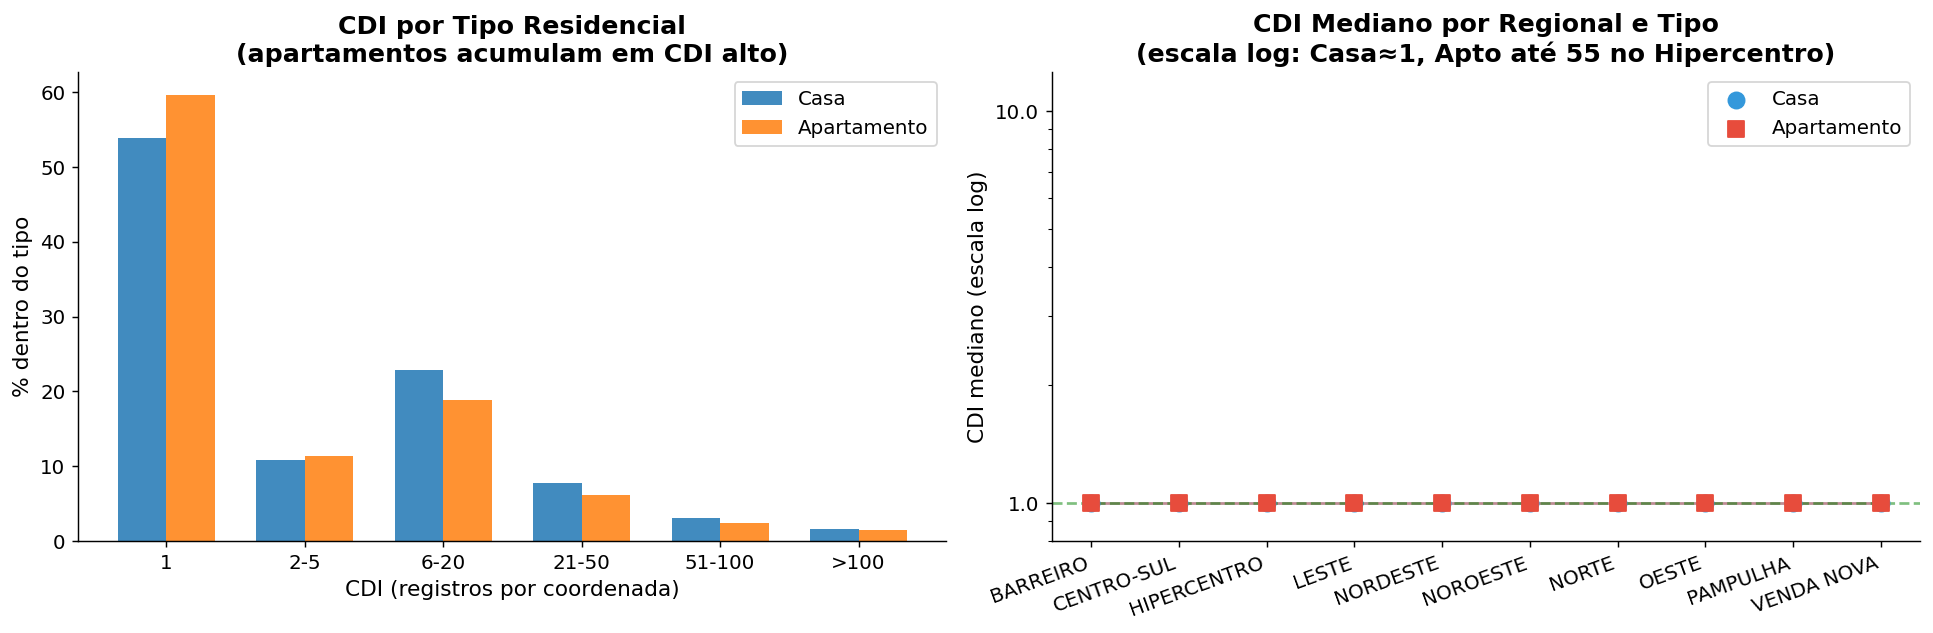

Casa: n=583,600 | CDI mediano=1 | CDI>10: 25.7% | CDI>50: 4.7%


Apartamento: n=399,645 | CDI mediano=1 | CDI>10: 20.9% | CDI>50: 3.8%


In [3]:
# 1.1 Distribuição do CDI por tipo residencial
domicilios = metrics[metrics['COD_ESPECIE'] == 1].copy()
tipo_map = {101: 'Casa', 102: 'Casa de Vila', 103: 'Apartamento', 104: 'Outros'}
domicilios['tipo_label'] = domicilios['COD_TIPO_ESPECI'].map(tipo_map).fillna('Desconhecido')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição CDI por tipo (barras agrupadas por faixa)
ax = axes[0]
cdi_bins = [1, 2, 6, 21, 51, 101, metrics['cdi'].max()+1]
cdi_labels = ['1', '2-5', '6-20', '21-50', '51-100', '>100']

for tipo in ['Casa', 'Apartamento']:
    sub = domicilios[domicilios['tipo_label'] == tipo]['cdi'].dropna()
    cats = pd.cut(sub, bins=cdi_bins, labels=cdi_labels, right=False)
    pcts = cats.value_counts(normalize=True).sort_index() * 100
    ax.bar(np.arange(len(cdi_labels)) + (0.35 if tipo == 'Apartamento' else 0),
           pcts.values, 0.35, label=tipo, alpha=0.85)

ax.set_xticks(np.arange(len(cdi_labels)) + 0.175)
ax.set_xticklabels(cdi_labels)
ax.set_xlabel('CDI (registros por coordenada)')
ax.set_ylabel('% dentro do tipo')
ax.set_title('CDI por Tipo Residencial\n(apartamentos acumulam em CDI alto)', fontweight='bold')
ax.legend()

# CDI mediano por regional × tipo (escala log para evitar compressão de Casa contra Apto)
ax = axes[1]
if 'NOME_REGIO' in domicilios.columns:
    regs_order = (domicilios[domicilios['tipo_label'] == 'Apartamento']
                  .groupby('NOME_REGIO')['cdi'].median()
                  .sort_values(ascending=False).index)
    x_pos = range(len(regs_order))
    for tipo, color, marker in [('Casa', '#3498db', 'o'), ('Apartamento', '#e74c3c', 's')]:
        sub = domicilios[domicilios['tipo_label'] == tipo]
        cdi_reg = sub.groupby('NOME_REGIO')['cdi'].median().reindex(regs_order)
        ax.scatter(x_pos, cdi_reg.values, color=color, label=tipo, s=80, zorder=3, marker=marker)
        ax.plot(x_pos, cdi_reg.values, color=color, alpha=0.5, linewidth=1.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(regs_order, rotation=20, ha='right')
    ax.set_yscale('log')
    ax.set_ylabel('CDI mediano (escala log)')
    ax.set_title('CDI Mediano por Regional e Tipo\n(escala log: Casa≈1, Apto até 55 no Hipercentro)',
                 fontweight='bold')
    ax.legend()
    ax.axhline(1, linestyle='--', color='green', alpha=0.5)
    ax.set_ylim(bottom=0.8)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb06_cdi_por_tipo.png', bbox_inches='tight')
plt.show()

# Estatísticas resumo
for tipo in ['Casa', 'Apartamento']:
    sub = domicilios[domicilios['tipo_label'] == tipo]['cdi'].dropna()
    print(f"{tipo}: n={len(sub):,} | CDI mediano={sub.median():.0f} | CDI>10: {(sub>10).mean()*100:.1f}% | CDI>50: {(sub>50).mean()*100:.1f}%")

Casa (n=583.600): CDI mediano=1, CDI>10 em 25,7%, CDI>50 em 4,7%. Apartamento (n=399.645): CDI mediano=1, CDI>10 em 20,9%. Na escala municipal, a maioria das casas e dos apartamentos tem coordenada única (mediana 1); o colapso de coordenadas por edifício não separa casa de apartamento de forma generalizada. Ele se concentra nos eixos centrais verticalizados (Hipercentro, CDI mediano 55), onde os edifícios altos elevam o CDI. Casas em vilas e condomínios horizontais também compartilham coordenada, o que explica sua parcela de CDI alto. O CDI distingue, portanto, contextos de adensamento, não a categoria tipológica isolada.

### 1.2 Impacto do CDI no GCI: PCI Arbitrário vs. PCI Empírico

No GCI_original (PCI arbitrário), todos os apartamentos recebem o mesmo PCI=0,5 independentemente do CDI, gerando GCI em dois patamares discretos (casas em torno de 0,85, apartamentos em torno de 0,45). No GCI_empírico (PCI=1/CDI), o GCI varia continuamente com o CDI: apartamentos com CDI baixo recebem PCI próximo de 1, enquanto edifícios com CDI alto recebem PCI próximo de 0. O PCI empírico discrimina dentro da categoria "apartamento" em vez de tratá-la como homogênea.

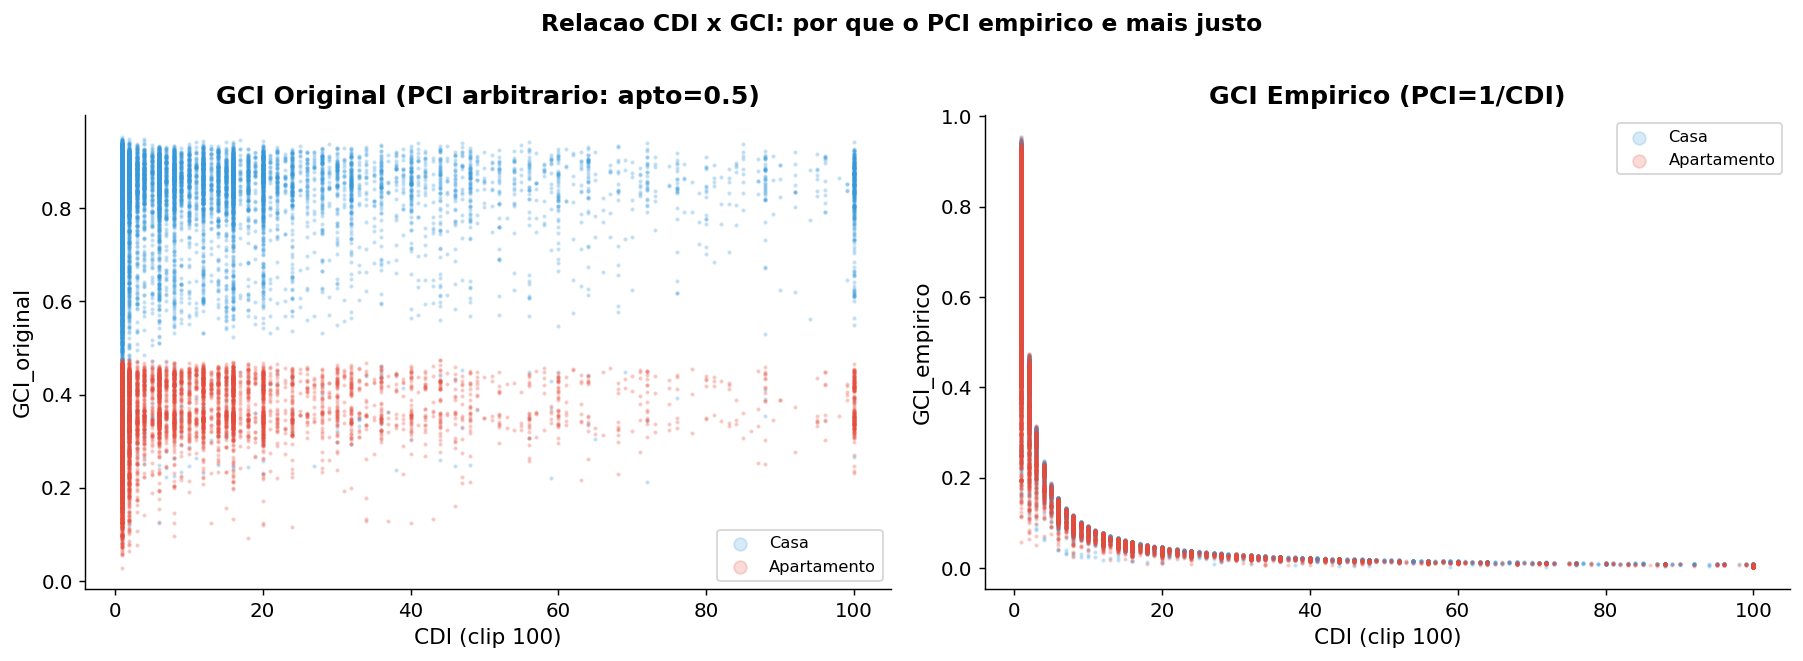

In [4]:
# 1.2 Impacto do CDI no PCI: arbitrario vs empirico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter CDI vs GCI_original vs GCI_empirico (amostra)
if 'GCI_original' in metrics.columns and 'GCI_empirico' in metrics.columns:
    sample = metrics[['cdi', 'GCI_original', 'GCI_empirico', 'COD_TIPO_ESPECI']].dropna().sample(
        min(30000, len(metrics)), random_state=42)
    sample['tipo_label'] = sample['COD_TIPO_ESPECI'].map(tipo_map).fillna('Outros')
    colors_tipo = {'Casa': '#3498db', 'Apartamento': '#e74c3c', 'Casa de Vila': '#2ecc71', 'Outros': '#95a5a6'}

    for ax, (gci_col, titulo) in zip(axes, [
        ('GCI_original', 'GCI Original (PCI arbitrario: apto=0.5)'),
        ('GCI_empirico', 'GCI Empirico (PCI=1/CDI)'),
    ]):
        for tipo in ['Casa', 'Apartamento']:
            sub = sample[sample['tipo_label'] == tipo]
            ax.scatter(sub['cdi'].clip(upper=100), sub[gci_col],
                       color=colors_tipo[tipo], s=2, alpha=0.2, label=tipo)
        ax.set_xlabel('CDI (clip 100)')
        ax.set_ylabel(gci_col)
        ax.set_title(titulo, fontweight='bold')
        ax.legend(markerscale=5, fontsize=9)

    plt.suptitle('Relacao CDI x GCI: por que o PCI empirico e mais justo',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_cdi_gci.png', bbox_inches='tight')
    plt.show()

---
## 2. Consolidação: de Registros para Edifícios

A consolidação agrupa registros que pertencem ao mesmo edifício físico usando a chave `logradouro + número + coordenada GPS (arredondada a 1 m)`. O CEP foi excluído da chave porque pode variar entre unidades do mesmo edifício, impedindo a consolidação correta.

In [5]:
# 2.1 Estatisticas da consolidacao por regional

if 'NOME_REGIO' in edificios.columns:
    reg_stats = edificios.groupby('NOME_REGIO').agg(
        n_edificios=('n_unidades', 'count'),
        n_verticais=('is_vertical', 'sum'),
        media_unidades=('n_unidades', 'mean'),
        gci_orig_med=('GCI_original', 'median'),
        gci_emp_med=('GCI_empirico', 'median'),
    ).round(3)
    reg_stats['pct_verticais'] = reg_stats['n_verticais'] / reg_stats['n_edificios'] * 100
    reg_stats = reg_stats.sort_values('media_unidades', ascending=False)

    display(reg_stats[['n_edificios', 'n_verticais', 'pct_verticais', 'media_unidades',
                          'gci_orig_med', 'gci_emp_med']].round(2).style
        .background_gradient(subset=['pct_verticais', 'media_unidades'], cmap='OrRd')
        .background_gradient(subset=['gci_orig_med', 'gci_emp_med'], cmap='RdYlGn', vmin=0.3, vmax=0.9)
        .format({'n_edificios': '{:,.0f}', 'n_verticais': '{:,.0f}', 'pct_verticais': '{:.1f}%',
                 'media_unidades': '{:.2f}', 'gci_orig_med': '{:.3f}', 'gci_emp_med': '{:.3f}'})
        .set_caption('Estatísticas por regional — nível de edifício'))

    # Registros originais por regional para comparacao
    if 'NOME_REGIO' in metrics.columns:
        orig_reg = metrics.groupby('NOME_REGIO').size().rename('n_registros')
        reg_stats['n_registros'] = orig_reg
        reg_stats['fator_compressao'] = reg_stats['n_registros'] / reg_stats['n_edificios']

        display(reg_stats[['n_registros', 'n_edificios', 'fator_compressao']].round(2).style
            .background_gradient(subset=['fator_compressao'], cmap='OrRd')
            .format({'n_registros': '{:,.0f}', 'n_edificios': '{:,.0f}', 'fator_compressao': '{:.2f}x'})
            .set_caption('Fator de compressão por regional (registros / edifícios)'))

,n_edificios,n_verticais,pct_verticais,media_unidades,gci_orig_med,gci_emp_med
NOME_REGIO,,,,,,
HIPERCENTRO,"4,854",576,11.9%,4.41,0.770,0.530
CENTRO-SUL,"48,225","8,748",18.1%,2.82,0.780,0.580
OESTE,"83,063","9,796",11.8%,1.87,0.820,0.600
PAMPULHA,"69,726","7,874",11.3%,1.78,0.850,0.610
LESTE,"75,895","6,818",9.0%,1.46,0.830,0.590
NOROESTE,"89,887","6,731",7.5%,1.41,0.820,0.580
NORDESTE,"104,012","8,828",8.5%,1.40,0.830,0.580
VENDA NOVA,"95,817","5,993",6.2%,1.25,0.850,0.610
NORTE,"81,510","4,924",6.0%,1.24,0.850,0.570


,n_registros,n_edificios,fator_compressao
NOME_REGIO,,,
HIPERCENTRO,"21,404","4,854",4.41x
CENTRO-SUL,"135,835","48,225",2.82x
OESTE,"155,121","83,063",1.87x
PAMPULHA,"123,924","69,726",1.78x
LESTE,"111,005","75,895",1.46x
NOROESTE,"127,140","89,887",1.41x
NORDESTE,"145,064","104,012",1.39x
VENDA NOVA,"120,200","95,817",1.25x
NORTE,"100,884","81,510",1.24x


O `cnefe_edificios.parquet` agrupa por (logradouro, número, coordenada GPS arredondada a 1 m), criando um registro único por edificação. O fator de compressão por regional confirma o gradiente esperado: Hipercentro e Centro-Sul com fatores > 2× (muitos apartamentos por edifício), Barreiro e Norte com fatores ≈ 1× (casas horizontais).

## 2.2 Painel Comparativo: Registros vs Edifícios

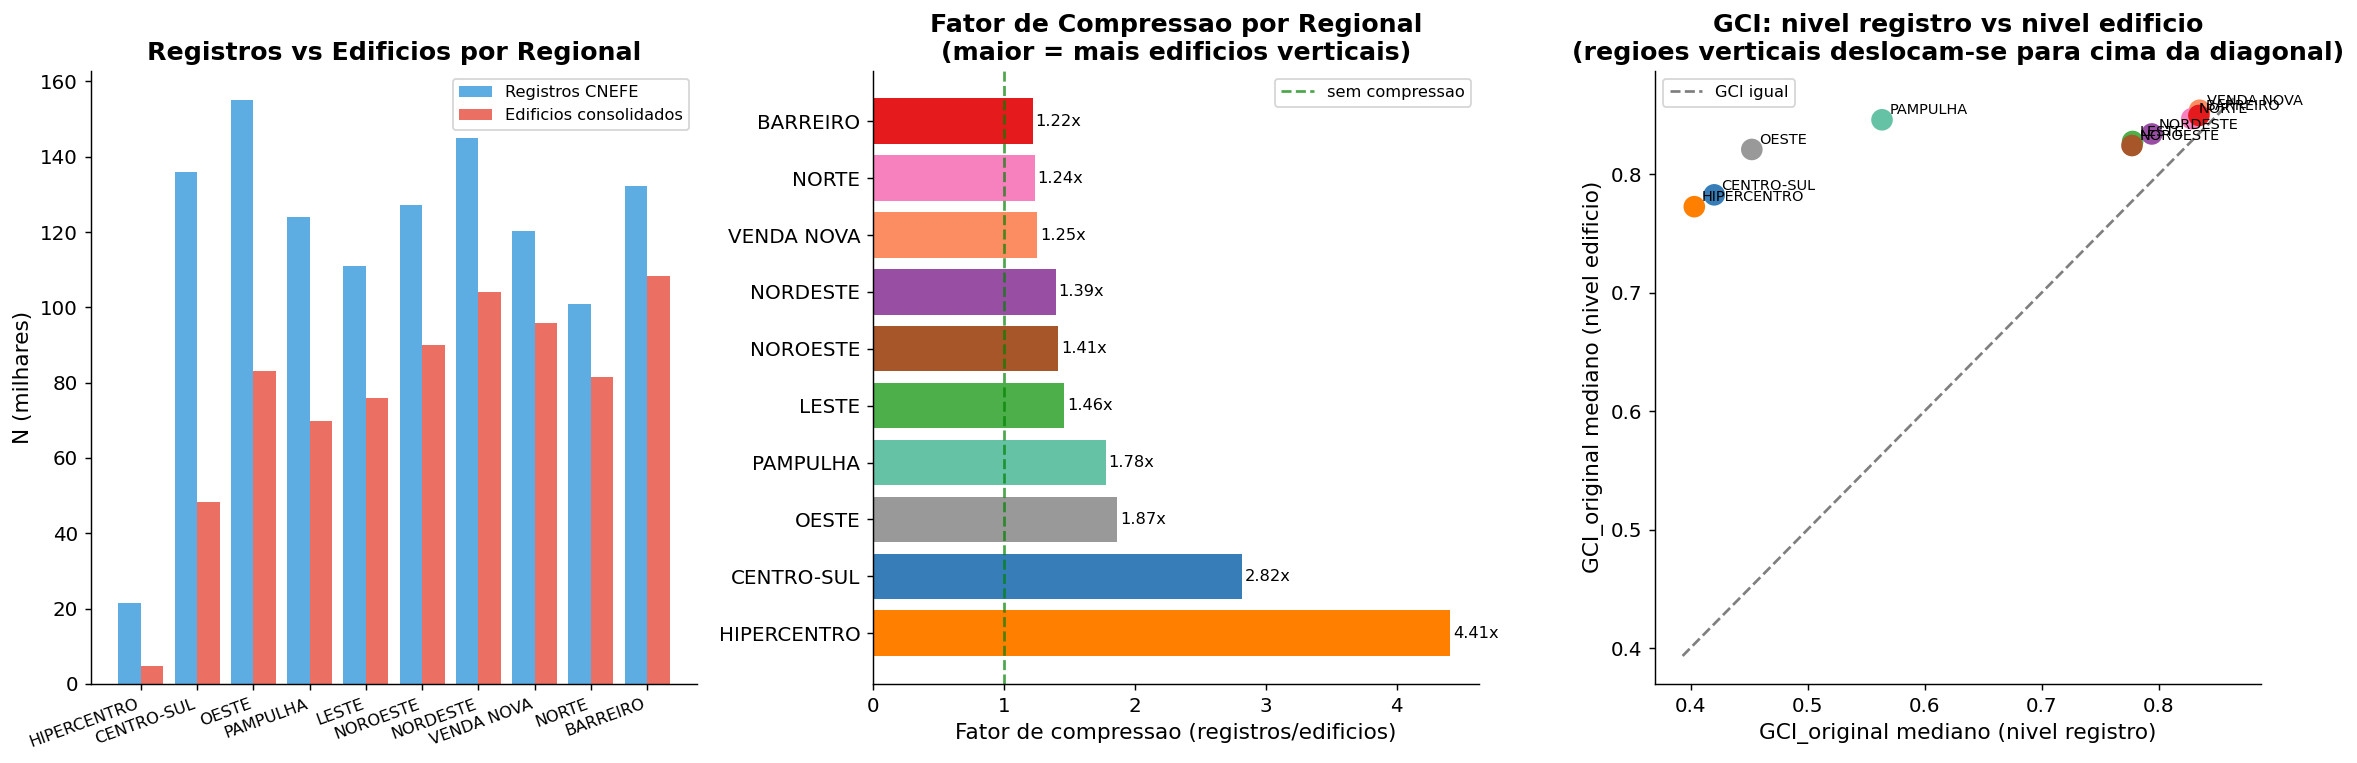

In [6]:
# 2.2 Painel: comparacao registros vs edificios por regional
if 'NOME_REGIO' in edificios.columns and 'NOME_REGIO' in metrics.columns:
    orig_reg = metrics.groupby('NOME_REGIO').size().rename('n_registros')
    edif_reg = edificios.groupby('NOME_REGIO').size().rename('n_edificios')
    compare = pd.concat([orig_reg, edif_reg], axis=1).dropna()
    compare['fator'] = compare['n_registros'] / compare['n_edificios']
    compare = compare.sort_values('fator', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    regs = compare.index
    colors = [PALETA_REGIONAL.get(r, '#aaaaaa') for r in regs]

    # N registros vs edificios
    ax = axes[0]
    x = np.arange(len(regs))
    ax.bar(x - 0.2, compare['n_registros'] / 1000, 0.4, label='Registros CNEFE', color='#3498db', alpha=0.8)
    ax.bar(x + 0.2, compare['n_edificios'] / 1000, 0.4, label='Edificios consolidados', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(regs, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('N (milhares)')
    ax.set_title('Registros vs Edificios por Regional', fontweight='bold')
    ax.legend(fontsize=9)

    # Fator de compressao
    ax = axes[1]
    bars = ax.barh(regs, compare['fator'], color=colors)
    ax.axvline(1, color='green', linestyle='--', alpha=0.7, label='sem compressao')
    ax.set_xlabel('Fator de compressao (registros/edificios)')
    ax.set_title('Fator de Compressao por Regional\n(maior = mais edificios verticais)', fontweight='bold')
    for bar, val in zip(bars, compare['fator']):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}x', va='center', fontsize=9)
    ax.legend(fontsize=9)

    # GCI por regional: registros vs edificios
    ax = axes[2]
    if 'GCI_original' in edificios.columns and 'GCI_original' in metrics.columns:
        gci_reg_orig = metrics.groupby('NOME_REGIO')['GCI_original'].median().reindex(compare.index)
        gci_reg_edif = edificios.groupby('NOME_REGIO')['GCI_original'].median().reindex(compare.index)
        ax.scatter(gci_reg_orig, gci_reg_edif,
                   c=[PALETA_REGIONAL.get(r, '#aaa') for r in compare.index],
                   s=120, zorder=3)
        for r in compare.index:
            ax.annotate(r, (gci_reg_orig[r], gci_reg_edif[r]),
                        textcoords='offset points', xytext=(4, 3), fontsize=8)
        lim_min = min(gci_reg_orig.min(), gci_reg_edif.min()) - 0.01
        lim_max = max(gci_reg_orig.max(), gci_reg_edif.max()) + 0.01
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.5, label='GCI igual')
        ax.set_xlabel('GCI_original mediano (nivel registro)')
        ax.set_ylabel('GCI_original mediano (nivel edificio)')
        ax.set_title('GCI: nivel registro vs nivel edificio\n(regioes verticais deslocam-se para cima da diagonal)',
                     fontweight='bold')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_compressao_regional.png', bbox_inches='tight')
    plt.show()

Fator de compressão varia por regional: Hipercentro e Centro-Sul têm mais registros por edifício que as periferias. O Hipercentro concentra os CDIs mais altos, o que justifica a discordância entre GCI_original e GCI_empírico nessa regional. O padrão socioespacial em si é fraco (ver NB11) e entra como contexto, não como contribuição.

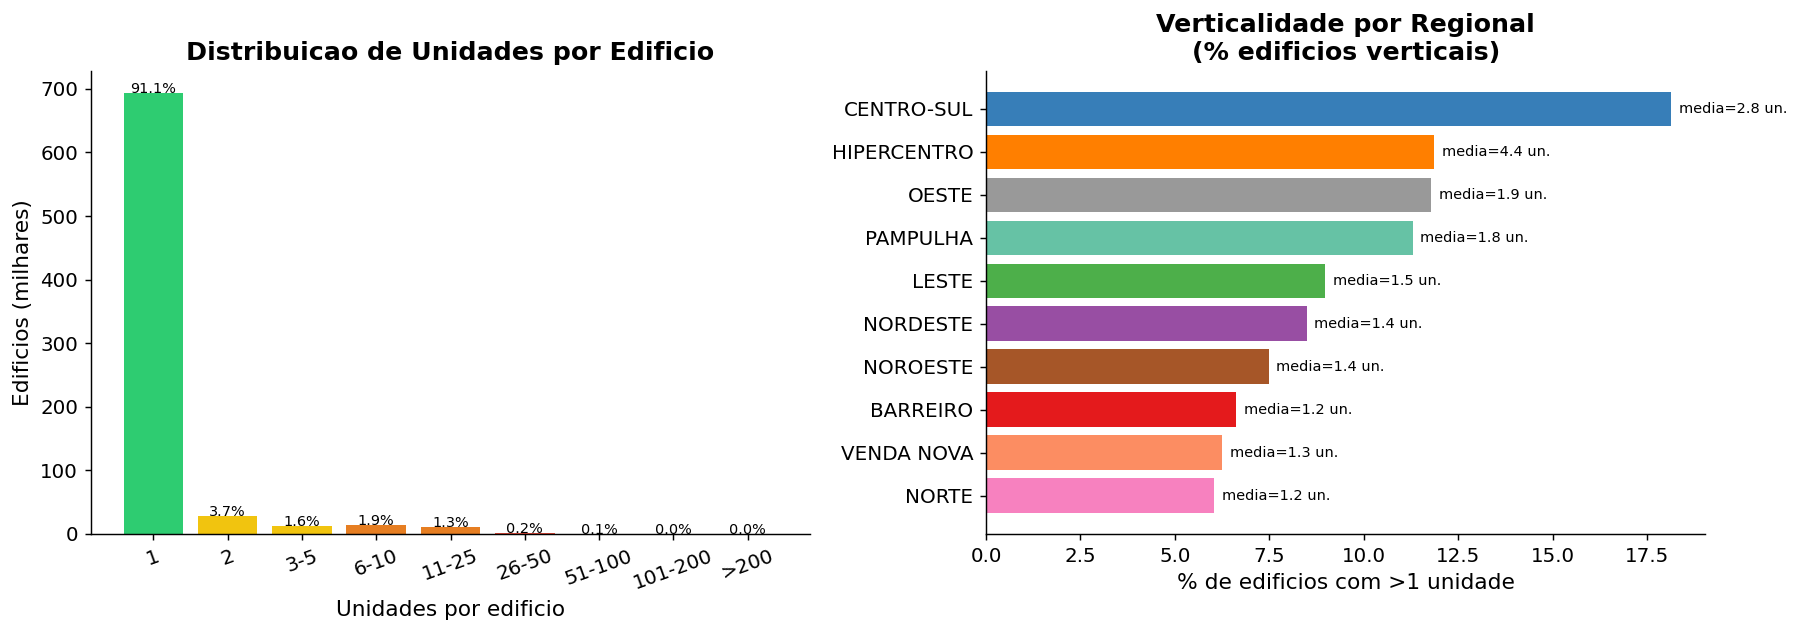

Edificios verticais (>1 unidade): 67,475 (8.9% dos edificios)
Registros em edificios verticais: 478,966 (40.8% dos registros)
Maior edificio: 287 unidades


In [7]:
# 2.3 Distribuicao de unidades por edificio (histograma)
if 'n_unidades' in edificios.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma global (log scale)
    ax = axes[0]
    bins = [1, 2, 3, 6, 11, 26, 51, 101, 201, edificios['n_unidades'].max()+1]
    labels_bins = ['1', '2', '3-5', '6-10', '11-25', '26-50', '51-100', '101-200', '>200']
    cats = pd.cut(edificios['n_unidades'], bins=bins, labels=labels_bins, right=False)
    vc = cats.value_counts().sort_index()
    colors_hist = ['#2ecc71' if i==0 else '#f1c40f' if i<3 else '#e67e22' if i<5 else '#e74c3c'
                   for i in range(len(labels_bins))]
    bars = ax.bar(labels_bins, vc.values/1000, color=colors_hist)
    ax.set_xlabel('Unidades por edificio')
    ax.set_ylabel('Edificios (milhares)')
    ax.set_title('Distribuicao de Unidades por Edificio', fontweight='bold')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val/len(edificios)*100:.1f}%', ha='center', fontsize=8)
    ax.tick_params(axis='x', rotation=20)

    # Edificios com >1 unidade por regional
    ax = axes[1]
    if 'NOME_REGIO' in edificios.columns:
        vert_reg = edificios.groupby('NOME_REGIO').agg(
            pct_vert=('is_vertical', 'mean'),
            media_unid=('n_unidades', 'mean')
        ).sort_values('pct_vert', ascending=True)
        colors_v = [PALETA_REGIONAL.get(r, '#aaa') for r in vert_reg.index]
        ax.barh(vert_reg.index, vert_reg['pct_vert']*100, color=colors_v)
        ax.set_xlabel('% de edificios com >1 unidade')
        ax.set_title('Verticalidade por Regional\n(% edificios verticais)', fontweight='bold')
        for i, (_, row) in enumerate(vert_reg.iterrows()):
            ax.text(row['pct_vert']*100 + 0.2, i,
                    f'media={row["media_unid"]:.1f} un.', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb06_unidades_edificio.png', bbox_inches='tight')
    plt.show()

    n_vert = edificios['is_vertical'].sum()
    n_unidades_vert = edificios[edificios['is_vertical']]['n_unidades'].sum()
    print(f"Edificios verticais (>1 unidade): {n_vert:,} ({n_vert/len(edificios)*100:.1f}% dos edificios)")
    print(f"Registros em edificios verticais: {n_unidades_vert:,} ({n_unidades_vert/len(metrics)*100:.1f}% dos registros)")
    print(f"Maior edificio: {edificios['n_unidades'].max():.0f} unidades")

---
## 3. Efeito da Consolidação no GCI

Comparação do GCI antes (nível registro) e após (nível edifício) a consolidação, isolando o efeito do PCI arbitrário sobre edifícios verticais.

In [8]:
# 3.1 GCI comparação nível edifício (nivel registro redundante com NB05)
if 'GCI_empirico' in metrics.columns:
    print(f"Nível registro: GCI_emp mediana={metrics['GCI_empirico'].median():.3f} | "
          f"GCI_orig mediana={metrics['GCI_original'].median():.3f}")
    print("Ver NB05 para distribuição completa e histogramas do GCI em nível de registro.")


Nível registro: GCI_emp mediana=0.577 | GCI_orig mediana=0.750
Ver NB05 para distribuição completa e histogramas do GCI em nível de registro.


A consolidação não altera significativamente a distribuição de GCI_empírico em nível de registro individual, mas muda a unidade de análise. Análises em nível de edifício (NB07 em diante) usam os registros consolidados para evitar viés de contagem, um edifício de 100 apartamentos não deve ter 100× mais peso que uma casa.

In [9]:

# 3.2 Tabela resumo para dissertação
if 'GCI_original' in edificios.columns and 'NOME_REGIO' in edificios.columns:
    rows = []
    for reg in sorted(metrics['NOME_REGIO'].dropna().unique()):
        m_sub = metrics[metrics['NOME_REGIO'] == reg]
        e_sub = edificios[edificios['NOME_REGIO'] == reg]
        rows.append({
            'Regional': reg,
            'N_registros': len(m_sub),
            'N_edificios': len(e_sub),
            'Fator_compressao': len(m_sub) / max(len(e_sub), 1),
            'Pct_vertical': e_sub['is_vertical'].mean() * 100 if len(e_sub) > 0 else np.nan,
            'GCI_orig_med_reg': m_sub['GCI_original'].median(),
            'GCI_orig_med_edif': e_sub['GCI_original'].median(),
            'GCI_emp_med_edif': e_sub['GCI_empirico'].median(),
        })

    tab = pd.DataFrame(rows).set_index('Regional').round(3)
    tab['delta_GCI_orig'] = (tab['GCI_orig_med_edif'] - tab['GCI_orig_med_reg']).round(3)

    display(tab.style
        .background_gradient(subset=['Fator_compressao'], cmap='OrRd')
        .background_gradient(subset=['GCI_orig_med_reg', 'GCI_orig_med_edif', 'GCI_emp_med_edif'],
                              cmap='RdYlGn', vmin=0.3, vmax=0.9)
        .background_gradient(subset=['delta_GCI_orig'], cmap='RdYlGn', vmin=-0.1, vmax=0.5)
        .format({'N_registros': '{:,.0f}', 'N_edificios': '{:,.0f}',
                 'Fator_compressao': '{:.2f}x', 'Pct_vertical': '{:.1f}%',
                 'GCI_orig_med_reg': '{:.3f}', 'GCI_orig_med_edif': '{:.3f}',
                 'GCI_emp_med_edif': '{:.3f}', 'delta_GCI_orig': '{:+.3f}'})
        .set_caption('Síntese por regional: registros vs edifícios\n'
                     'delta_GCI_orig = GCI edifício − GCI registro (positivo = melhora com consolidação)'))

    tab.to_csv(config.TAB_DIR / 'nb06_consolidacao_edificios_regional.csv')
    print("Salvo: consolidacao_edificios_regional.csv")
    print("\nNota: delta_GCI_orig muito alto (ex: CENTRO-SUL +0.35) indica regional altamente")
    print("verticalizada onde o GCI médio era artificialmente rebaixado pela contagem múltipla de apts.")

,N_registros,N_edificios,Fator_compressao,Pct_vertical,GCI_orig_med_reg,GCI_orig_med_edif,GCI_emp_med_edif,delta_GCI_orig
Regional,,,,,,,,
BARREIRO,"132,325","108,422",1.22x,6.6%,0.834,0.850,0.583,+0.016
CENTRO-SUL,"135,835","48,225",2.82x,18.1%,0.420,0.783,0.582,+0.363
HIPERCENTRO,"21,404","4,854",4.41x,11.9%,0.403,0.773,0.532,+0.370
LESTE,"111,005","75,895",1.46x,9.0%,0.778,0.828,0.587,+0.050
NORDESTE,"145,064","104,012",1.40x,8.5%,0.794,0.834,0.582,+0.040
NOROESTE,"127,140","89,887",1.41x,7.5%,0.777,0.824,0.581,+0.047
NORTE,"100,884","81,510",1.24x,6.0%,0.828,0.847,0.572,+0.019
OESTE,"155,121","83,063",1.87x,11.8%,0.452,0.821,0.601,+0.369
PAMPULHA,"123,924","69,726",1.78x,11.3%,0.564,0.846,0.606,+0.282


Salvo: consolidacao_edificios_regional.csv

Nota: delta_GCI_orig muito alto (ex: CENTRO-SUL +0.35) indica regional altamente
verticalizada onde o GCI médio era artificialmente rebaixado pela contagem múltipla de apts.


Centro-Sul e Hipercentro mostram o maior delta entre GCI_original e GCI_empírico, confirmando que são as regiões onde o PCI arbitrário mais subestimava a incerteza real. Barreiro, Norte e Venda Nova têm delta próximo de zero, casas horizontais com CDI=1 não são afetadas pela mudança de método.

## Conclusão do Notebook 06

Este notebook quantificou e contextualizou o viés de verticalização no CDI. Os achados centrais são:

- **CDI por tipo:** casas e apartamentos têm CDI mediano=1 na escala municipal; o colapso de coordenadas concentra-se nos edifícios altos do centro (Hipercentro: CDI mediano de apartamentos ≈ 55; Barreiro ≈ 1), não na categoria apartamento em geral.
- **Consolidação:** 1.172.902 registros → 761.411 edifícios (redução de 35,1%), refletindo a proporção de unidades em edifícios verticais.
- **Impacto no GCI:** Centro-Sul e Hipercentro mostram o maior delta entre GCI_original e GCI_empírico (+0,35 no Centro-Sul), confirmando que são as regiões onde o PCI arbitrário mais subestimava a incerteza real ao penalizar todo apartamento com 0,5.
- **Hipótese H1:** confirmada pelo **erro posicional** (apartamentos com erro mediano ~2× o das casas). No GCI_empírico a diferença é negligível (r=−0,10), pois o CDI mediano é 1 para ambos; o efeito grande r=−0,97 pertence ao GCI_original, onde o PCI binário separa as tipologias por construção.
- **Resultado para a dissertação (C2):** o PCI_empírico = 1/CDI discrimina pelo grau de adensamento (verticalização real do edifício), não pela etiqueta casa/apartamento, corrigindo o ponto em que o método arbitrário era mais inadequado: os edifícios altos do centro.